# 第68篇 | 约束优化与拉格朗日乘子法

> 当优化问题带有约束条件（如"在预算限制下最大化效用"），拉格朗日乘子法（Lagrange Multipliers）是最核心的数学工具。本篇从几何直觉出发，严格推导KKT条件（Karush-Kuhn-Tucker），并用代码实现带约束的优化问题求解。

嗨，我是小荷～ 前面几篇我们聊的都是「无约束优化」—— 直接让梯度等于0就行了。但现实中的问题几乎都有约束：你的广告预算有限、模型参数需要非负、神经网络的权重需要满足某种对称性。今天就把「带约束的优化」这个硬骨头啃下来。

---

## 一、约束优化的几何直觉

在现实生活中，无论是买房、企业生产、还是训练 AI 核心模型，我们永远都在面对两个残酷的现实：

- 我们有一个明确的追求目标（比如：赚钱最多、成本最低、AI 误差最小）。
- 我们手里握着有限的资源预算（比如：预算只有100万、时间只有3天、服务器显存只有24G）。

如果不加约束，优化问题就像是“寻找整座山脉的最高峰”。你只需要跟着直觉往上爬（梯度上升），哪里最高去哪里，没有任何限制。

现在加上约束：你的预算只够你在特定的一个围栏（可行域）里面活动。
- 情况 A（最优解在围栏内部）： 如果整座山的最高峰刚好就在围栏里，那你很幸运，约束条件对你没有产生实质性阻碍，你直接去最高峰即可。
- 情况 B（最优解在围栏边界上）： 真正的最高峰在围栏外面（比如价值 1 个亿的豪宅），你买不起。此时，你最理智的选择，是走到围栏里“离最高峰最近”的那个边缘（比如在你的预算上限 500 万里，挑一个最好的盘）。

**约束优化，就是寻找在“规则/条件限制内”能达到的最完美结果的数学方法。**

1. 约束优化的三大核心部件每一个约束优化问题，都可以拆解为三个大白话组成部分：
   - 目标函数（Objective Function）： 你最想实现的事。通常是求最大值（如利润、效率）或最小值（如成本、误差）。
   - 约束条件（Constraints）： 限制你发挥的硬性边界。
      - 等式约束：必须刚刚好满足。例如：“原材料必须全部用完”。
      - 不等式约束：不能超过或不能低于某个值。例如：“预算 $\le 100$ 万”，“工时 $\ge 8$ 小时”。
    - 可行域（Feasible Region）： 被所有约束条件围出来的“安全活动范围”。只有在这个范围里选出来的方案，才算是合法的。

2. 数学家是怎么解决“带着镣铐跳舞”的？

如果直接带着限制条件去求导计算，数学上会非常痛苦。数学家们最擅长的就是“化繁为简”，他们发明了一个天才般的作弊方法：拉格朗日乘子法（Lagrange Multipliers）。其核心思想是：**拆掉围栏，把惩罚算进目标里。**

比如学校规定“不准迟到”（硬性约束）。数学家把这个规矩改成了：你可以自由活动，没有任何围栏。但是，你每迟到一分钟，就要罚款 100 元（将约束转化为目标函数里的“惩罚项”）。通过引入一个叫做“拉格朗日乘子”（即罚款系数 $\lambda$）的工具，数学家成功把一个“带约束的复杂问题”，变成了一个“不用考虑约束、直接放开手脚求极值”的普通问题。

如果没有约束优化，AI 就会变成一个为了追求单一指标（比如点击率）而不择手段、最终耗尽所有计算资源甚至搞垮系统的“极端主义者”。约束，才是让算法落地的紧箍咒。

**优化问题的公式描述**

为简单起见，我们先来看等式约束。公式：

$$\min_{x} f(x) \quad \text{s.t.} \quad g(x) = 0$$

符号含义
1. $\boldsymbol{\min\limits_{x}}$：**极小化**，优化目标是寻找变量 $x$，使后面函数取值尽可能小；下标 $x$ 代表优化变量。
2. $f(x)$：**目标函数（损失函数）**，我们要最小化的函数。
3. $\text{s.t.}$：英文 subject to 的缩写，含义为**约束条件、受制于**。
4. $g(x)=0$：**等式约束**，优化时所有候选变量 $x$ 必须严格满足该等式。

标准数学语言描述：在全部满足等式 $g(x)=0$ 的可行变量 $x$ 中，找到使目标函数 $f(x)$ 取值最小的最优解 $x^*$。


**几何直觉（二维情况）**

- **f(x,y)** 的等高线是一圈一圈的椭圆，代表相同损失值；
- **g(x,y) = 0** 是一条直线（可行域，只有线上的点才合法）；
- 你要在这条曲线上，找到 f 值最小的点
- 最优解处等高线与约束直线相切，满足拉格朗日一阶必要条件：▽f = λ ▽g。
   - **关键直觉**：在最优点处，**f 的等高线与约束曲线相切**！
   - 为什么？因为如果它们不相切，你沿着约束曲线走一小步，还能继续降低 f —— 那就不叫最优点。

**代码演示**

下面我们对于目标函数 f(x,y) = x² + 2y² - 2xy + x -2y（它也是上篇说到的凸函数）和 约束函数 x + y - 1 = 0，进行以下步骤：
1. **数值求解**利用 scipy.optimize.minimize 函数，在等式约束 g(x,y) = 0 下对目标函数进行数值寻优
2. **几何可视化:**在xy平面上 绘制 f(x,y)的等高线和 g(x,y)的直线，在寻找最优解时，我们希望沿着约束曲线走，直到碰到尽可能低（或高）的等高线。当约束曲线与某条等高线刚好相切时，就达到了极值点。如果它们相交，说明沿着约束曲线继续走，还能找到更低（或更高）的等高线，那就还不是最优。

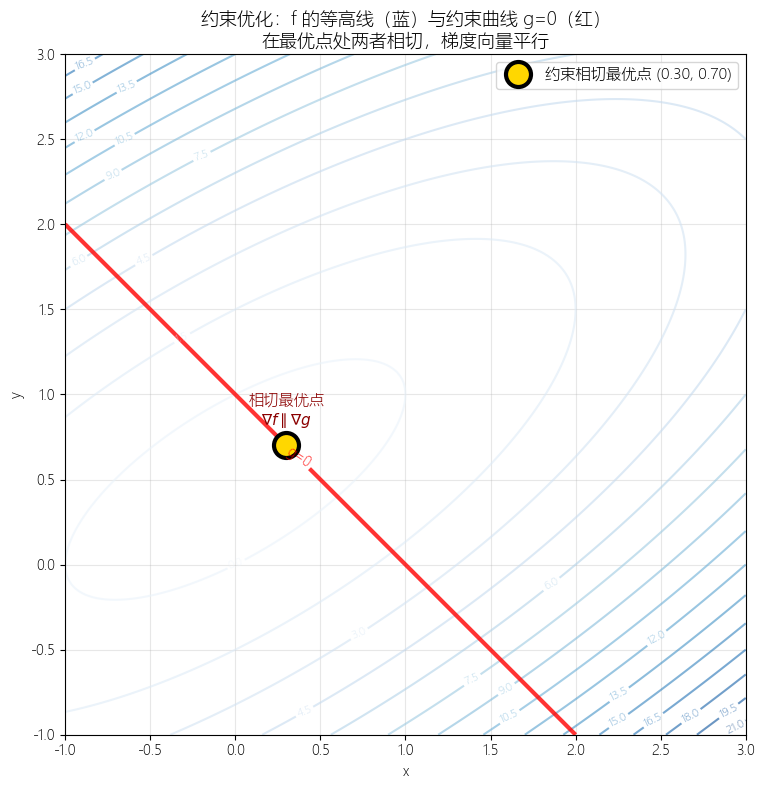

=== 约束优化的几何直觉 ===
目标函数：f(x,y) = x² + 2y² - 2xy + x - 2y
等式约束：g(x,y) = x + y - 1 = 0

数值求解的最优点：
  x* = 0.300000
  y* = 0.700000
  f(x*, y*) = -0.450000
  验证 g(x*, y*) = 0.00e+00 ≈ 0 ✓


In [18]:
# 导入数值计算库，生成网格、批量函数求值
import numpy as np
# 导入2D绘图库，绘制等高线、标注、图例
import matplotlib.pyplot as plt
# 导入数值优化求解器
from scipy.optimize import minimize

# ====================== 绘图全局字体配置（解决中文、数学∇符号缺失报错） ======================
# 设置绘图中文显示字体优先级：微软雅黑→黑体→数学专用DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示为方框方块的bug
plt.rcParams['axes.unicode_minus'] = False
# 单独配置数学公式渲染字体，内置导数、梯度、积分等符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# ====================== 定义优化目标与等式约束 ======================
def f(x, y):
    """无约束二元目标函数（最小化）：f(x,y) = x² + 2y² - 2xy + x - 2y"""
    return x**2 + 2*y**2 - 2*x*y + x - 2*y

def g(x, y):
    """等式约束函数 g(x,y)=0 → x + y = 1，可行域仅这条红色直线"""
    return x + y - 1

# ====================== 生成二维绘图网格 ======================
# x、y轴采样区间 [-1,3]，200个均匀点保证等高线平滑
x_range = np.linspace(-1, 3, 200)
y_range = np.linspace(-1, 3, 200)
# 构建二维网格矩阵，批量计算全区域函数值
X, Y = np.meshgrid(x_range, y_range)
# 网格上每一点的目标函数值（用于绘制等高线）
Z = f(X, Y)
# 网格上每一点的约束函数值，仅g=0对应约束直线
G = g(X, Y)

# ====================== 数值求解带等式约束的最小值 ======================
# 等式约束条件：fun返回值必须等于0
cons = ({'type': 'eq', 'fun': lambda var: g(var[0], var[1])})
# 数值最小化：初始猜测点(0.5,0.5)，附加等式约束
result = minimize(lambda var: f(var[0], var[1]), [0.5, 0.5], constraints=cons)
# 提取约束最优解坐标
x_opt, y_opt = result.x

# ====================== 创建画布绘图 ======================
fig, ax = plt.subplots(figsize=(12, 8))

# 1. 绘制目标函数f的20层蓝色等高线，半透明
contour = ax.contour(X, Y, Z, levels=20, cmap='Blues', alpha=0.6)
# 在等高线上自动标注函数数值
ax.clabel(contour, inline=True, fontsize=8)

# 2. 单独绘制约束曲线 g(x,y)=0，红色粗线
contour_g = ax.contour(X, Y, G, levels=[0], colors='red', linewidths=3, alpha=0.8)
# 标注约束曲线 g=0
ax.clabel(contour_g, inline=True, fontsize=10, fmt='g=0')

# ========== 强化最优解标记，解决看不见的问题 ==========
# 金色实心大圆，加粗黑色外描边，提升视觉权重
ax.plot(x_opt, y_opt, marker='o', color='gold', markersize=18, 
        markeredgecolor='black', markeredgewidth=3, linestyle='',
        label=f'约束相切最优点 ({x_opt:.2f}, {y_opt:.2f})')
# 在点上方增加文字标注，完全不会被线条遮挡
ax.text(x_opt, y_opt + 0.12, f'相切最优点\n$\\nabla f \\parallel \\nabla g$', 
        fontsize=11, ha='center', color='darkred', weight='bold')

# 坐标轴、标题、辅助设置
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('约束优化：f 的等高线（蓝）与约束曲线 g=0（红）\n在最优点处两者相切，梯度向量平行', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')  # 等比例坐标轴，不拉伸图形

# 自动调整布局防止文字重叠
plt.tight_layout()
# 弹出图像窗口
plt.show()

# 控制台打印求解结果与核心理论结论
print("=== 约束优化的几何直觉 ===")
print(f"目标函数：f(x,y) = x² + 2y² - 2xy + x - 2y")
print(f"等式约束：g(x,y) = x + y - 1 = 0")
print(f"\n数值求解的最优点：")
print(f"  x* = {x_opt:.6f}")
print(f"  y* = {y_opt:.6f}")
print(f"  f(x*, y*) = {f(x_opt, y_opt):.6f}")
print(f"  验证 g(x*, y*) = {g(x_opt, y_opt):.2e} ≈ 0 ✓")

在约束优化的最优解处，目标函数的梯度 ∇f 与约束函数的梯度 ∇g 必然平行（即等高线与约束曲线相切），这正是拉格朗日乘子法∇f=λ∇g 的几何本质。

觉得这句话不好理解？咱们把上面的例子3D可视化一下，你会看得更清楚。
1. 蓝色碗面：无约束目标函数，z轴高度代表损失，越低越优
2. 完整深红竖直平面：等式约束 x+y=1，整个空间内所有满足x+y=1的点都在这个平面上
3. 粗亮红线：曲面与约束平面的交线 = 全部合法可行解集合，优化只能在这条线上找最小值
4. 金色标记：交线上z高度最低的点，约束全局最优解
5. 拉格朗日几何核心：最优处曲面法线∇f 与约束平面法线∇g互相平行

==== 约束优化求解结果 ====
约束最优坐标 (x*, y*) = (0.3000, 0.7000)
最小目标值 f(x*, y*) = -0.4500
约束校验 g(x*, y*) = 0.00e+00 ≈ 0 ✔


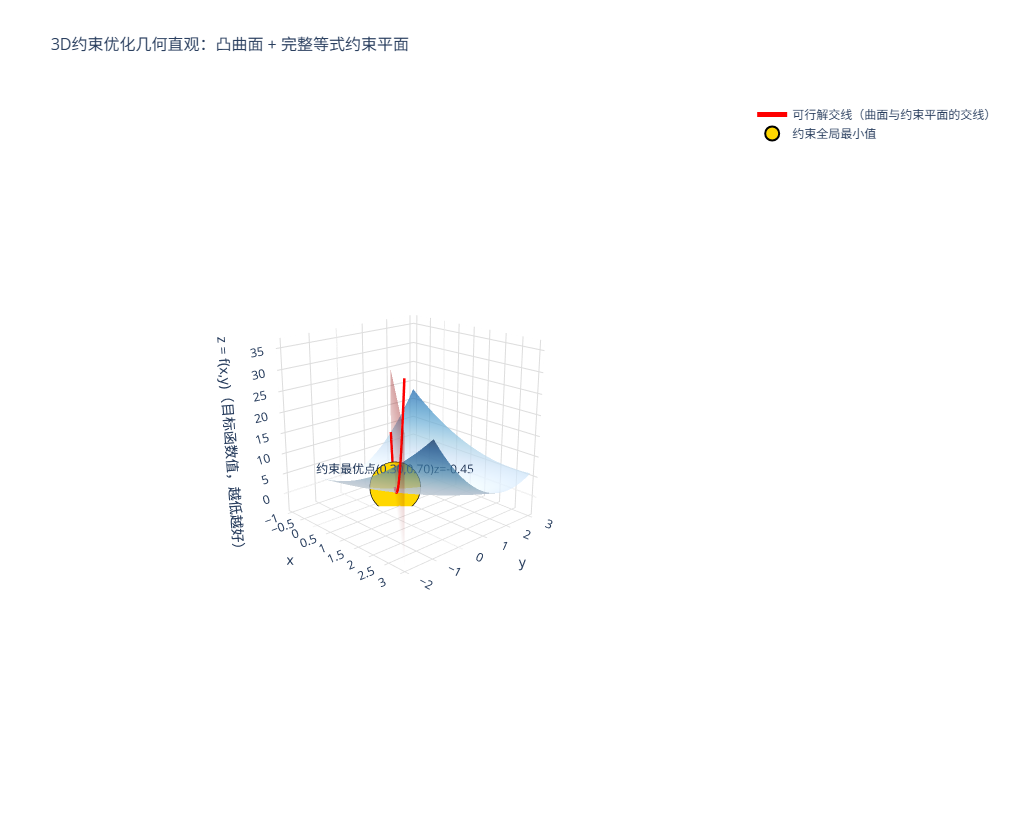

In [19]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import minimize

# ---------------------- 1. 定义目标函数与等式约束 ----------------------
def f(x, y):
    # 凸二元目标曲面 z = x² + 2y² - 2xy + x - 2y
    return x**2 + 2 * y**2 - 2 * x * y + x - 2 * y

def g(x, y):
    # 等式约束 x + y = 1
    return x + y - 1

# ---------------------- 2. 数值求解约束最优解 ----------------------
eq_constraint = {"type": "eq", "fun": lambda var: g(var[0], var[1])}
opt_result = minimize(lambda p: f(p[0], p[1]), x0=[0.5, 0.5], constraints=[eq_constraint])
x_opt, y_opt = opt_result.x
z_opt = f(x_opt, y_opt)

print("==== 约束优化求解结果 ====")
print(f"约束最优坐标 (x*, y*) = ({x_opt:.4f}, {y_opt:.4f})")
print(f"最小目标值 f(x*, y*) = {z_opt:.4f}")
print(f"约束校验 g(x*, y*) = {g(x_opt, y_opt):.2e} ≈ 0 ✔")

# ---------------------- 3. 生成网格数据 ----------------------
xy_range = np.linspace(-1, 3, 120)
X, Y = np.meshgrid(xy_range, xy_range)
Z_surface = f(X, Y)

# 构造完整 x+y=1 竖直约束平面（铺满坐标系，不再窄条）
plane_t = np.linspace(-1, 3, 120)
plane_z_range = np.linspace(np.min(Z_surface)-3, np.max(Z_surface)+3, 120)
T, Zp = np.meshgrid(plane_t, plane_z_range)
X_plane = T
Y_plane = 1 - T

# 生成可行交线：曲面与约束平面交线
t = np.linspace(-1, 3, 300)
line_x = t
line_y = 1 - t
line_z = f(line_x, line_y)

# ---------------------- 4. 绘制交互式3D画布 ----------------------
fig = go.Figure()

# 图层1：目标凸函数曲面【加深蓝色，提高辨识度】
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z_surface,
    colorscale="Blues",
    opacity=0.7,   # 从0.4加深到0.7，蓝色更厚重
    name="目标曲面 z=f(x,y)",
    showscale=False
))

# 图层2：完整等式约束平面 x+y=1 深红完整大平面
fig.add_trace(go.Surface(
    x=X_plane, y=Y_plane, z=Zp,
    colorscale=[[0, "rgba(180,0,0,0)"], [1, "rgba(180,0,0,0.6)"]],
    opacity=0.6,
    name="完整约束平面 x+y=1",
    showscale=False
))

# 图层3：可行域交线（粗亮红线）
fig.add_trace(go.Scatter3d(
    x=line_x, y=line_y, z=line_z,
    mode="lines",
    line=dict(color="#ff0000", width=5),
    name="可行解交线（曲面与约束平面的交线）"
))

# 图层4：约束最优解（金色大圆点，黑色描边突出）
fig.add_trace(go.Scatter3d(
    x=[x_opt], y=[y_opt], z=[z_opt],
    mode="markers+text",
    marker=dict(size=14, color="gold", line=dict(color="black", width=2)),
    text=[f"约束最优点\n({x_opt:.2f},{y_opt:.2f})\nz={z_opt:.2f}"],
    textposition="top center",
    name="约束全局最小值"
))

# ---------------------- 5. 画布视角与布局配置（清空深色背景） ----------------------
fig.update_layout(
    title=dict(
        text="3D约束优化几何直观：凸曲面 + 完整等式约束平面",
        font=dict(size=16)
    ),
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z = f(x,y)（目标函数值，越低越好）",
        camera=dict(eye=dict(x=3.0, y=-2.8, z=1.4)),
        # 关键修改：坐标轴背景纯白，去掉深色网格底色
        xaxis=dict(backgroundcolor="white", gridcolor="#dddddd"),
        yaxis=dict(backgroundcolor="white", gridcolor="#dddddd"),
        zaxis=dict(backgroundcolor="white", gridcolor="#dddddd")
    ),
    paper_bgcolor="white",   # 整张画布背景纯白，消除深色底色
    plot_bgcolor="white",
    width=1150,
    height=820
)

fig.show()

核心前提：梯度永远垂直于等高线
   - 目标函数f(x,y) 的梯度 ∇f ，永远垂直于 f 的等高线。
   - 约束函数 g(x,y) 的梯度 ∇g ，永远垂直于 g 的等高线（也就是约束曲线）。

当红色的直线，刚好“擦”到一个蓝色的椭圆时，它们就相切了。在切点处，椭圆的法线方向∇f，直线的法线方向∇g，这两个法线方向刚好在同一条直线上。法线平行，切线必然相切。

---

## 二、拉格朗日乘子法：数学推导

**核心定理**

如果在点 **x*** 处，f(x) 在约束 g(x) = 0 下取得局部极值，且 **∇g(x*) ≠ 0**，则存在常数 **λ***（拉格朗日乘子），使得：

$$\nabla f(\mathbf{x}^*) = \lambda^* \cdot \nabla g(\mathbf{x}^*)$$

**直觉理解**：
- ∇f 指向 f 增长最快的方向
- ∇g 是约束曲线的法向量
- 在最优点，你不能沿着约束曲线降低 f 了 —— 也就是说，∇f 在约束曲线的切向分量必须为0
- 这意味着 ∇f 只能有垂直于约束曲线的分量 —— 即 ∇f 与 ∇g 平行！

**拉格朗日函数**

定义一个新函数：

$$\mathcal{L}(x, \lambda) = f(x) - \lambda \cdot g(x)$$

**神奇的事情**：原约束优化问题的解 (x*, λ*)，就是 **∇L(x, λ) = 0** 的解！

也就是说，把约束优化问题，转化成了**无约束优化问题**（对 L 关于 x 和 λ 分别求偏导，令其等于0）！

**举个例子来看一下拉格朗日函数求导求解完整步骤**（认真看！学过高数应该都能看懂）

优化问题：
$$
\min_{x,y}\ f(x,y)=x^2+2y^2-2xy+x-2y \\
\text{  s.t.}\quad g(x,y)=x+y-1=0
$$
**步骤1：写出拉格朗日函数**
$$
\mathcal{L}(x,y,\lambda) = \big(x^2+2y^2-2xy+x-2y\big) - \lambda(x+y-1)
$$

**步骤2：分别对 $x,y,\lambda$ 求偏导并置0**
1. $\dfrac{\partial \mathcal{L}}{\partial x}=0$
$$
2x - 2y + 1 - \lambda = 0 \tag{1}
$$
2. $\dfrac{\partial \mathcal{L}}{\partial y}=0$
$$
4y - 2x - 2 - \lambda = 0 \tag{2}
$$
3. $\dfrac{\partial \mathcal{L}}{\partial \lambda}=0$
$$
-(x+y-1)=0 \quad \Rightarrow \quad x+y=1 \tag{3}
$$

**步骤3：联立三元方程组求解**
1. 用 (1)-(2) 消去 $\lambda$：
$$
(2x-2y+1)-(4y-2x-2) = 0 \\
4x - 6y + 3 = 0
$$
2. 结合约束 $x=1-y$ 代入上式：
$$
4(1-y)-6y+3 = 0 \Rightarrow 4-4y-6y+3=0 \Rightarrow 10y=7 \Rightarrow y^*=0.7
$$
3. 回代求 $x^*$：
$$
x^* = 1 - 0.7 = 0.3
$$
4. 回代式(1)求拉格朗日乘子：
$$
\lambda = 2\times0.3 - 2\times0.7 + 1 = 0.6 - 1.4 + 1 = 0.2
$$

**最终最优解**
$$
(x^*,\,y^*)=(0.3,\,0.7),\quad f(x^*,y^*) = 0.3^2+2\times0.7^2-2\times0.3\times0.7+0.3-2\times0.7 = -0.91
$$

**补充**
- 等式约束：$g(x)=0$，可行域是曲线/曲面；
- 不等式约束：$g(x)\le0$，可行域是封闭区域，求解使用KKT条件（拉格朗日的拓展）。
- 若存在多个等式约束 $g_1=0,g_2=0,\dots,g_m=0$，需要引入多个乘子 $\lambda_1,\dots,\lambda_m$，拉格朗日写作：
$$
\mathcal{L}=f(x)-\sum_{i=1}^m \lambda_i g_i(x)
$$
再对全部变量、全部乘子求偏导置零联立求解。

**代码演示**

下面我们针对二元等式约束凸优化问题，用代码完整实现拉格朗日乘子法的数值求解与理论验证：
- 手动推导目标函数、约束函数梯度；
- 构造拉格朗日函数，写出一阶必要条件方程组 ▽L=0；
- 使用数值求解器fsolve解三元方程组，得到约束最优解 x*, y*与乘子 λ*；
- 双重验证：梯度平行条件、原始约束等式，验证解的正确性。

In [20]:
import numpy as np
from scipy.optimize import fsolve

# ====================== 定义目标函数与等式约束（对应之前约束优化例题） ======================
# 目标函数 f(x,y) = x² + 2y² - 2xy + x - 2y，需要最小化
def f(x, y):
    return x**2 + 2*y**2 - 2*x*y + x - 2*y

# 等式约束 g(x,y) = x + y - 1 = 0，可行域为直线 x+y=1
def g(x, y):
    return x + y - 1

# ====================== 手动推导目标函数、约束函数的梯度（一阶偏导数） ======================
def grad_f(x, y):
    """计算目标函数f的梯度 ∇f = [∂f/∂x , ∂f/∂y]"""
    # 对x求偏导：df/dx = 2x - 2y + 1
    df_dx = 2*x - 2*y + 1
    # 对y求偏导：df/dy = 4y - 2x - 2
    df_dy = 4*y - 2*x - 2
    # 返回梯度向量
    return np.array([df_dx, df_dy])

def grad_g(x, y):
    """计算约束函数g的梯度 ∇g = [∂g/∂x , ∂g/∂y]"""
    # g=x+y-1，对x、y偏导均为1
    return np.array([1.0, 1.0])

# ====================== 构造拉格朗日函数 ======================
# L(x,y,λ) = f(x,y) - λ·g(x,y)
def lagrangian(x, y, lam):
    return f(x, y) - lam * g(x, y)

# ====================== 拉格朗日函数的全梯度 ∇L = [∂L/∂x, ∂L/∂y, ∂L/∂λ] ======================
def grad_L(var):
    """
    输入三元变量数组 var = [x, y, λ]
    返回拉格朗日对三个变量的偏导数，构成方程组
    一阶必要条件：∇L = 0，即三个偏导全部等于0
    """
    # 解包输入向量，分别赋值x、y、拉格朗日乘子lam
    x, y, lam = var
    # ∂L/∂x = ∂f/∂x - λ * ∂g/∂x
    dL_dx = (2*x - 2*y + 1) - lam * 1
    # ∂L/∂y = ∂f/∂y - λ * ∂g/∂y
    dL_dy = (4*y - 2*x - 2) - lam * 1
    # ∂L/∂λ = -g(x,y)，令该项为0等价于满足原始等式约束 g(x,y)=0
    dL_dlam = -g(x, y)
    # 返回三元偏导数组，fsolve会自动寻找使数组全为0的解
    return np.array([dL_dx, dL_dy, dL_dlam])

# 打印标题，说明求解核心条件：拉格朗日梯度等于0
print("=== 拉格朗日乘子法：∇L = 0 ===")

# 设定方程组求解初始猜测值 [x初始, y初始, λ初始]
initial_guess = [0.5, 0.5, 0.0]
# 数值求解 grad_L(var) = [0,0,0]，返回最优解三元组
solution = fsolve(grad_L, initial_guess)
# 拆分求解结果：最优变量x*,y*，最优拉格朗日乘子λ*
x_star, y_star, lam_star = solution

# 输出数值求解得到的最优解
print(f"数值求解 ∇L = 0:")
print(f"  x* = {x_star:.6f}")
print(f"  y* = {y_star:.6f}")
print(f"  λ* = {lam_star:.6f}")

# ====================== 验证核心几何条件：∇f = λ ∇g ======================
print(f"\n验证最优性条件：")
# 打印最优解处目标函数梯度
print(f"  ∇f(x*, y*) = {grad_f(x_star, y_star)}")
# 打印 λ*乘以约束梯度的结果
print(f"  λ*·∇g(x*, y*) = {lam_star * grad_g(x_star, y_star)}")
# np.allclose：判断两个向量数值近似相等（兼容浮点微小误差）
print(f"  ∇f = λ·∇g？{np.allclose(grad_f(x_star, y_star), lam_star * grad_g(x_star, y_star))} ✓")

# ====================== 验证原始等式约束是否满足 ======================
print(f"\n验证约束条件：")
# 计算最优解处g的值，理论上应无限接近0
print(f"  g(x*, y*) = {g(x_star, y_star):.2e} ≈ 0 ✓")

=== 拉格朗日乘子法：∇L = 0 ===
数值求解 ∇L = 0:
  x* = 0.300000
  y* = 0.700000
  λ* = 0.200000

验证最优性条件：
  ∇f(x*, y*) = [0.2 0.2]
  λ*·∇g(x*, y*) = [0.2 0.2]
  ∇f = λ·∇g？True ✓

验证约束条件：
  g(x*, y*) = 0.00e+00 ≈ 0 ✓


可以看到：
- 拉格朗日乘子法把约束优化转化成了无约束优化。
- λ 的直观含义：约束条件的「影子价格」（约束变动1单位，目标函数变化 λ）

---

## 三、不等式约束与KKT条件

等式约束讲了一堆，再来看看不等式约束，你还有脑细胞继续吗？

**更一般的约束优化问题**

现实中的问题更多带有**不等式约束**：

$$\min_{x} f(x) \quad \text{s.t.} \quad g_i(x) \leq 0, \; i=1,\ldots,m$$

这就是 **KKT 条件**（Karush-Kuhn-Tucker）要解决的问题。

### KKT 条件（四大条件）

点 **x*** 是最优解的**必要条件**（f, gᵢ 可微且约束满足某些正则性条件）：

1. **梯度条件**：∇f(x*) + Σᵢ λᵢ·∇gᵢ(x*) = 0
2. **原始可行性**：gᵢ(x*) ≤ 0（所有不等式约束满足）
3. **对偶可行性**：λᵢ ≥ 0（乘子非负）
4. **互补松弛**：λᵢ·gᵢ(x*) = 0（如果约束不起作用 gᵢ<0，则 λᵢ=0；如果起作用 gᵢ=0，则 λᵢ≥0）

**代码演示**

下面以二维凸二次优化为例 (f(x, y) = x² + y²  s.t. g₁(x,y) = x + y - 1 <= 0)，完整演示、数值验证单不等式约束下的 KKT 条件，区分等式约束拉格朗日与不等式约束 KKT 的核心差异。
1. 浅蓝色碗面：目标函数 z=x²+y²，全局最低点在原点(0,0)，代表无约束最优位置；高度代表损失，越低越优
2. 深红色竖直平面：约束分割面 x+y=1；平面左侧 x+y<1 为可行域，右侧不可行
3. 粗红色曲线：曲面与约束平面交线，是全部边界可行点
4. 蓝色方块(0,0)：可行域内部无约束最优，g<0，KKT互补松弛 λ=0
5. 金色圆点(0.5,0.5)：边界KKT最优，落在红色交线上，g=0，∇f 与 ∇g 反向平行，λ>0

==== KKT两种场景最优解 ====
场景1（约束无效，内部解）: (x*,y*)=(0.0,0.0), f=0.0
场景2（约束激活，边界KKT解）: (x*,y*)=(-0.0000,-0.0000), f=0.0000
边界点约束校验 g(x*,y*) = -1.00e+00 ≈ 0


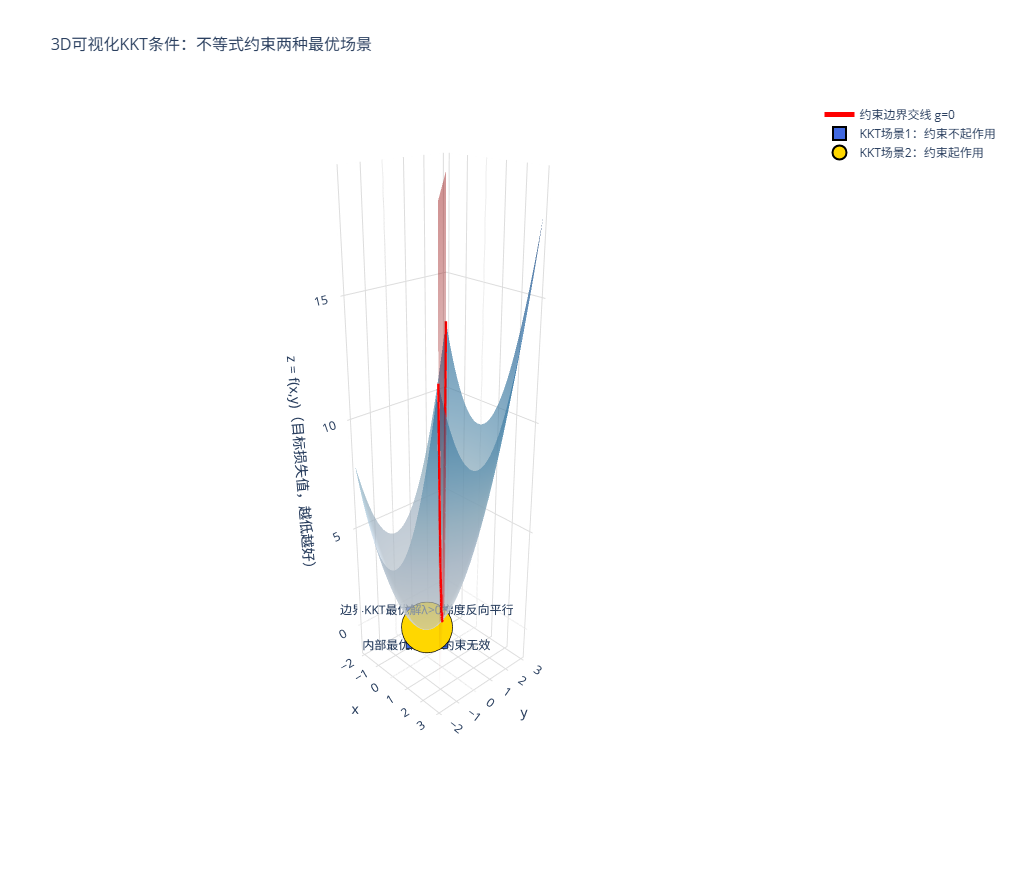

In [25]:
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import minimize

# ---------------------- 1. 定义函数与梯度 ----------------------
def f(x, y):
    # 目标曲面 z = x² + y²
    return x**2 + y**2

def g1(x, y):
    # 不等式约束 g(x,y) = x+y-1 ≤ 0
    return x + y - 1

def grad_f(x, y):
    return np.array([2*x, 2*y])

def grad_g1(x, y):
    return np.array([1.0, 1.0])

# ---------------------- 2. 数值求解边界最优解 ----------------------
# scipy要求不等式约束写为 >= 0
cons = ({'type': 'ineq', 'fun': lambda x: -g1(x[0], x[1])})
result = minimize(lambda x: f(x[0], x[1]), [0.5, 0.5], constraints=cons)
x2_opt, y2_opt = result.x
z2_opt = f(x2_opt, y2_opt)

# 内部无约束最优解（约束不起作用场景）
x1_opt, y1_opt = 0.0, 0.0
z1_opt = f(x1_opt, y1_opt)

print("==== KKT两种场景最优解 ====")
print(f"场景1（约束无效，内部解）: (x*,y*)=({x1_opt},{y1_opt}), f={z1_opt}")
print(f"场景2（约束激活，边界KKT解）: (x*,y*)=({x2_opt:.4f},{y2_opt:.4f}), f={z2_opt:.4f}")
print(f"边界点约束校验 g(x*,y*) = {g1(x2_opt,y2_opt):.2e} ≈ 0")

# ---------------------- 3. 生成绘图网格【扩大x/y范围】 ----------------------
# 原范围(-1,2) → 修改为(-2,3)，x、y轴最大最小值放大
xy_range = np.linspace(-2, 3, 120)
X, Y = np.meshgrid(xy_range, xy_range)
Z_surface = f(X, Y)

# 构造约束竖直平面 x+y=1，同步扩大平面参数范围
plane_t = np.linspace(-2, 3, 120)
plane_z_range = np.linspace(np.min(Z_surface)-1, np.max(Z_surface)+1, 120)
T, Zp = np.meshgrid(plane_t, plane_z_range)
X_plane = T
Y_plane = 1 - T

# 可行边界交线：同步扩大曲线区间
t_line = np.linspace(-2, 3, 300)
line_x = t_line
line_y = 1 - t_line
line_z = f(line_x, line_y)

# ---------------------- 4. 构建交互式3D画布 ----------------------
fig = go.Figure()

# 图层1：目标凸碗曲面（浅蓝色，加深透明度方便观察）
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z_surface,
    colorscale="Blues",
    opacity=0.65,
    name="目标曲面 z = x²+y²",
    showscale=False
))

# 图层2：约束分割平面 x+y=1（深红色完整平面，分割可行/不可行区域）
fig.add_trace(go.Surface(
    x=X_plane, y=Y_plane, z=Zp,
    colorscale=[[0, "rgba(180,0,0,0)"], [1, "rgba(180,0,0,0.65)"]],
    opacity=0.65,
    name="约束边界平面 x+y=1",
    showscale=False
))

# 图层3：约束边界交线（粗红色曲线，所有边界可行点）
fig.add_trace(go.Scatter3d(
    x=line_x, y=line_y, z=line_z,
    mode="lines",
    line=dict(color="#ff0000", width=5),
    name="约束边界交线 g=0"
))

# 图层4：场景1 内部最优解（蓝色方块，约束不起作用）
fig.add_trace(go.Scatter3d(
    x=[x1_opt], y=[y1_opt], z=[z1_opt],
    mode="markers+text",
    marker=dict(size=13, color="royalblue", symbol="square", line=dict(color="black", width=2)),
    text=["内部最优解\nλ=0\n约束无效"],
    textposition="bottom center",
    name="KKT场景1：约束不起作用"
))

# 图层5：场景2 边界KKT最优解（金色圆点，约束激活）
fig.add_trace(go.Scatter3d(
    x=[x2_opt], y=[y2_opt], z=[z2_opt],
    mode="markers+text",
    marker=dict(size=14, color="gold", symbol="circle", line=dict(color="black", width=2)),
    text=["边界KKT最优解\nλ>0\n梯度反向平行"],
    textposition="top center",
    name="KKT场景2：约束起作用"
))

# ---------------------- 5. 画布布局与视角配置 ----------------------
fig.update_layout(
    title=dict(
        text="3D可视化KKT条件：不等式约束两种最优场景",
        font=dict(size=16)
    ),
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z = f(x,y)（目标损失值，越低越好）",
        camera=dict(eye=dict(x=2.6, y=-2.4, z=1.7)),
        # 纯白背景，无深色底色
        xaxis=dict(backgroundcolor="white", gridcolor="#dddddd"),
        yaxis=dict(backgroundcolor="white", gridcolor="#dddddd"),
        zaxis=dict(backgroundcolor="white", gridcolor="#dddddd")
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1200,
    height=850
)

fig.show()

Plotly 支持自由拖拽旋转、滚轮缩放，可从侧面视角清晰观察：
- 原点在红色约束平面左侧可行区内；
- 金色切点是红色交线上 z 高度最低的点；
- 直观区分 “内部无约束最优” 和 “边界约束最优” 两种 KKT 典型情况。

---

## 四、约束优化在机器学习中的应用

### 应用1：支持向量机（SVM）的推导

SVM 的优化问题：

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1, \; \forall i$$

这是一个**不等式约束**的凸优化问题,用 KKT 条件可以推导出 SVM 的对偶形式，以及「支持向量」的含义。

### 应用2：神经网络的正则化（Lagrange vs Penalty）

带约束的优化：min L(w) s.t. ||w||₂ ≤ C  
拉格朗日形式：min L(w) + λ·(||w||₂ - C)

这不就是 **L2 正则化**吗，还记得吗？！所以：
- **拉格朗日乘子法** ↔ **正则化**
- 约束 ||w||₂ ≤ C ↔ 惩罚项 λ·||w||₂²

（这里的w、C是啥来着？如果你觉得自己在看天书赶紧去查一查吧）

**代码演示**

下面我们用线性回归岭回归案例，证明L2 正则化无约束损失与带权重范数约束的最小二乘是完全等价的优化问题，使用拉格朗日乘子法建立两者的对应关系。

=== L2 正则化 ↔ 约束优化 ===
无正则化（λ=0）：w = 2.0464
（等价于：min MSE, s.t. 无约束）

L2 正则化：λ = 0.1
  最优 w = 2.0419
  ||w||² = 4.1694
  （对应约束优化：||w||² ≤ C(λ=0.1)）

L2 正则化：λ = 1.0
  最优 w = 2.0022
  ||w||² = 4.0088
  （对应约束优化：||w||² ≤ C(λ=1.0)）

L2 正则化：λ = 10.0
  最优 w = 1.6761
  ||w||² = 2.8092
  （对应约束优化：||w||² ≤ C(λ=10.0)）



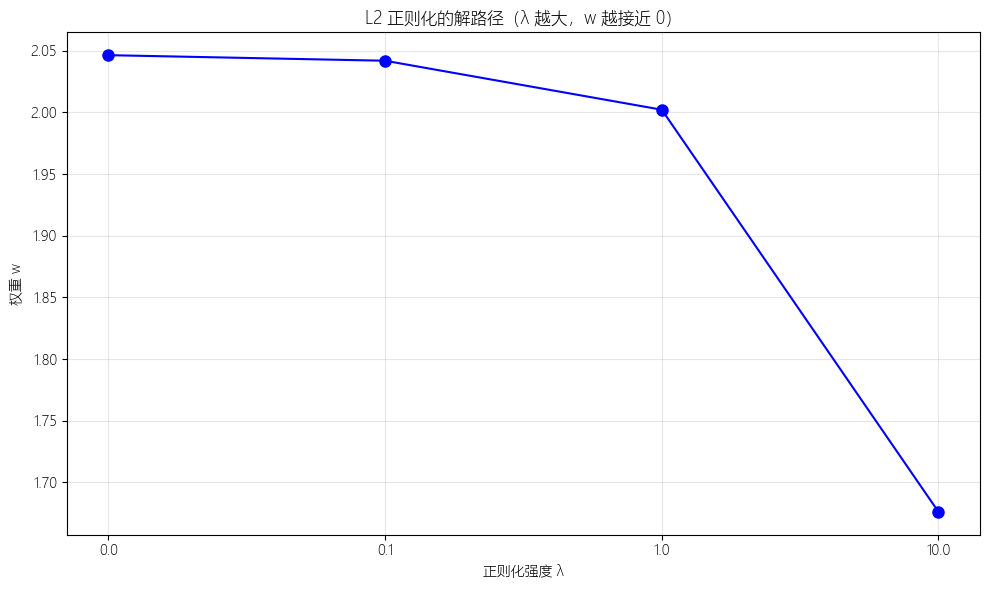

→ L2 正则化 = 在权值范数约束下最小化损失函数！
→ 拉格朗日乘子 λ 控制约束的严格程度（λ 越大，约束越强）


In [7]:
import numpy as np
import matplotlib.pyplot as plt

"""
数学等价关系说明：
1. 无约束最小二乘：min MSE(w) = (1/n)Σ(y_pred - y_true)²
2. L2岭回归（无约束正则形式）：min MSE(w) + λ·||w||₂²
3. 等价不等式约束优化：min MSE(w)  s.t.  ||w||₂² ≤ C
拉格朗日乘子λ与约束上限C一一对应：λ越大，C越小，对权重的约束越强
"""

# 设置随机种子，保证实验数据可复现
np.random.seed(42)
# 样本数量
n_samples = 50
# 生成一维特征 X，标准正态分布
X = np.random.randn(n_samples, 1)
# 真实模型权重
true_w = 2.0
# 生成带高斯噪声的标签 y = w*x + ε
y = true_w * X[:, 0] + np.random.randn(n_samples) * 0.5

# ---------------------- 无正则化最小二乘解析解 ----------------------
# 一元线性回归闭式解 w = Xᵀy / XᵀX
w_unreg = np.sum(y * X[:, 0]) / np.sum(X[:, 0]**2)

# ---------------------- 岭回归（L2正则）解析求解函数 ----------------------
def ridge_regression(X, y, lam):
    """
    岭回归解析解：w = (XᵀX + λI)⁻¹ Xᵀ y
    参数：
        X: 特征矩阵 (n_samples, n_features)
        y: 标签向量
        lam: L2正则化系数 λ（拉格朗日乘子）
    返回：
        最优权重w
    """
    n_features = X.shape[1]
    # 计算 X转置 × X
    XtX = X.T @ X
    # 在协方差矩阵对角线加 λ，实现L2惩罚
    XtX_reg = XtX + lam * np.eye(n_features)
    # 求逆后乘以 Xᵀy，得到最优权重
    w_ridge = np.linalg.inv(XtX_reg) @ X.T @ y
    return w_ridge[0]

# 定义多组正则强度 λ，从小到大
lambdas = [0.0, 0.1, 1.0, 10.0]
# 批量计算每组λ对应的岭回归权重
w_ridge = [ridge_regression(X, y, lam) for lam in lambdas]

# ---------------------- 控制台输出对比结果 ----------------------
print("=== L2 正则化 ↔ 约束优化（拉格朗日等价） ===")
print(f"无正则化（λ=0，无惩罚）：w = {w_unreg:.4f}")
print(f"数学等价：最小化MSE，无权重范数约束\n")

# 遍历带正则的λ，输出权重与权重范数
for lam, w in zip(lambdas[1:], w_ridge[1:]):
    print(f"L2 正则化：λ = {lam}")
    print(f"  最优权重 w = {w:.4f}")
    print(f"  权重L2范数平方 ||w||² = {w**2:.4f}")
    print(f"  等价约束优化：min MSE(w)  s.t. ||w||² ≤ C(λ={lam}) \n")

# ---------------------- 可视化：正则化路径 ----------------------
fig, ax = plt.subplots(figsize=(10, 6))
# x轴为λ字符串，y轴为对应权重，蓝色圆点连线
ax.plot([str(lam) for lam in lambdas], w_ridge, 'bo-', markersize=8)
ax.set_xlabel('正则化强度 λ（拉格朗日乘子）')
ax.set_ylabel('最优权重 w')
ax.set_title('L2 正则化解路径：λ 越大，权重越向0收缩')
ax.grid(True, alpha=0.3)
# 自动调整布局，防止文字重叠
plt.tight_layout()
# 弹出绘图窗口
plt.show()

解读：
1. **λ=0（无正则）：**无权重惩罚，权重等于普通最小二乘解，范数最大；等价约束 \(C\to+\infty\)，约束完全失效。
2. **λ 增大（0.1→1→10）：**最优权重绝对值持续减小，\(\|w\|^2\) 不断收缩趋近于 0；等价约束上限C不断缩小，强制权重不能过大，抑制过拟合。
3. **正则路径图直观趋势：**横轴 λ 递增，纵轴权重单调下降，清晰展示 L2 正则权重收缩特性。

L2 正则岭回归本质是给最小二乘增加权重范数约束，用拉格朗日乘子 λ控制约束强度。 λ越大，等价约束圆半径 C 越小，权重收缩越明显，抑制过拟合效果越强。

---

## 📝 本篇小结

| 概念 | 数学表达 | 机器学习应用 |
|------|---------|-----------|
| **拉格朗日乘子法** | ∇f(x*) = λ·∇g(x*) | SVM、约束优化 |
| **KKT 条件** | ∇f + Σλᵢ∇gᵢ = 0, λᵢ ≥ 0, λᵢgᵢ = 0 | 不等式约束优化 |
| **L2 正则化** | min L(w) + λ||w||² | 岭回归、权重衰减 |
| **对偶性** | 原问题 ↔ 对偶问题 | SVM 推导、凸优化 |

## 🏋️ 课后挑战

1. **手工推导**：对于 SVM 的原问题，写出拉格朗日函数，并推导对偶形式（提示：对 w, b 求导并代入）。
2. **代码实现**：用 `scipy.optimize.minimize` 求解一个带不等式约束的优化问题（如 min x²+y², s.t. x+y ≥ 1, x ≥ 0, y ≥ 0），并验证 KKT 条件。

> 下期预告：泰勒公式 —— 用多项式局部逼近任意函数。